# Sanity Checks — Energy Futures Meta-Model Pipeline
### Notebooks 2a (rb1s) · 2b (ho1s) · 2c (ng1s) · 2d (cl1s)

This notebook is **standalone and read-only with respect to the main pipeline**.
It reads the feature parquet produced by notebook 1 and the raw OHLCV CSV,
runs four sanity checks, and prints a clear PASS / WARN / FAIL verdict for
each instrument × check combination.

**The four checks are:**

| # | Check | What it catches |
|---|-------|-----------------|
| 1 | **Data leakage** | Labels that look more than 2 weeks into the future, future information sneaking into features |
| 2 | **Class imbalance** | Severely skewed meta-label distributions that would bias the classifiers |
| 3 | **Outliers** | Extreme feature values that corrupt scaling and distance-based models |
| 4 | **Stationarity** | Non-stationary features that violate the i.i.d. assumption most models rely on |

Run the notebook top-to-bottom. No cell has a side-effect on any other file.

## 0. Imports and Configuration

In [1]:
# Standard library
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Statistics
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Suppress KPSS convergence warnings — they are cosmetic for a sanity check
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*interpolation.*")

print("Imports OK")

Imports OK


In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
# All four instruments covered by notebooks 2a–2d.
INSTRUMENTS = {
    "rb1s": "RBOB Gasoline (2a)",
    "ho1s": "Heating Oil   (2b)",
    "ng1s": "Natural Gas   (2c)",
    "cl1s": "WTI Crude Oil (2d)",
}

# File paths — mirror the paths used in the main pipeline.
FEATURES_PATH = "../data/processed/features/features.parquet"
OHLCV_PATH    = "../data/src/ohlcv_data.csv"

# Triple-barrier parameters (must match the main notebooks exactly).
# The label horizon is [1, max_hold] trading days, so anything beyond
# max_hold trading days in the future is a leakage red flag.
TRIPLE_BARRIER_MAX_HOLD = 20   # trading days

# Class-imbalance thresholds.
# Warn if the minority class is below IMBALANCE_WARN_PCT of the dataset.
# Fail if it drops below IMBALANCE_FAIL_PCT.
IMBALANCE_WARN_PCT = 35   # %
IMBALANCE_FAIL_PCT = 20   # %

# Outlier detection: flag values beyond this many IQRs from the median.
OUTLIER_IQR_MULTIPLIER = 5.0

# Stationarity: ADF null = has unit root (non-stationary).
#               KPSS null = is stationary.
# We fail if more than this fraction of features are non-stationary per instrument.
STATIONARITY_FAIL_FRACTION = 0.30   # 30 %

# Signal start date used in the main notebooks (where label alignment begins).
SIGNAL_START = pd.Timestamp("2021-08-16")

print("Configuration OK")
print(f"  Instruments : {list(INSTRUMENTS.keys())}")
print(f"  Features    : {FEATURES_PATH}")
print(f"  OHLCV       : {OHLCV_PATH}")

Configuration OK
  Instruments : ['rb1s', 'ho1s', 'ng1s', 'cl1s']
  Features    : ../data/processed/features/features.parquet
  OHLCV       : ../data/src/ohlcv_data.csv


## 1. Load Data

We load:
- **Feature matrix** — the output of notebook 1 (`features.parquet`). One row per
  (date, instrument). Contains every Tier 1–4 feature plus `primary_signal`.
- **OHLCV** — the raw price data. We need the `close` column for the triple-barrier
  label reconstruction used in Check 1.

In [3]:
# Load feature matrix
features = pd.read_parquet(FEATURES_PATH)
features["date"] = pd.to_datetime(features["date"])
features = features.sort_values(["instrument", "date"]).reset_index(drop=True)

print(f"Feature matrix: {features.shape[0]:,} rows × {features.shape[1]} columns")
print(f"  Date range  : {features['date'].min().date()} → {features['date'].max().date()}")
print(f"  Instruments : {sorted(features['instrument'].unique())}")
print(f"  Signal rows : {features['primary_signal'].notna().sum():,}")

Feature matrix: 2,512 rows × 63 columns
  Date range  : 2020-01-03 → 2022-06-30
  Instruments : ['cl1s', 'ho1s', 'ng1s', 'rb1s']
  Signal rows : 2,512


In [4]:
# Load raw OHLCV (needed for label horizon reconstruction in Check 1)
ohlcv = pd.read_csv(OHLCV_PATH, parse_dates=["date"])
ohlcv = ohlcv[ohlcv["instrument"].isin(INSTRUMENTS)].sort_values(["instrument", "date"])

print(f"OHLCV: {ohlcv.shape[0]:,} rows")
print(f"  Date range  : {ohlcv['date'].min().date()} → {ohlcv['date'].max().date()}")

OHLCV: 32,614 rows
  Date range  : 1990-01-02 → 2022-06-30


In [5]:
# Identify feature columns (everything except the three meta columns).
META_COLS = ["date", "instrument", "primary_signal"]

feature_cols = [c for c in features.columns if c not in META_COLS]
print(f"Feature columns ({len(feature_cols)} total):")
print(feature_cols)

Feature columns (60 total):
['ret_1d', 'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d', 'vol_of_vol_20d', 'vol_ratio_5_60', 'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14', 'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high', 'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60', 'trend_tstat_best', 'trend_H_best', 'rel_ret_vs_basket_5d', 'corr_to_basket_60d', 'energy_basket_ret_5d', 'energy_basket_vol_20d', 'crack_321_proxy', 'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'winter_indicator', 'driving_season', 'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp', 'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age', 'hmm_basket_turbulent_energy', 'kmeans_cluster_id', 'kmeans_cluster_size', 'primary_signal_

---
## Check 1 — Data Leakage

**What we check:**

The triple-barrier labelling scheme assigns a label to each trade entry date `t₀`.
The label is determined by which barrier is hit first over the window `[t₀+1, t₀+max_hold]`.
If `max_hold = 20`, then the furthest the label can look into the future is **20 trading days**.

Any label whose exit date is more than 20 trading days after entry is a **leakage flag**,
because it means the label was formed using data that a model trained up to `t₀` could
not have seen.

We also verify that **features are strictly backward-looking** by checking that the feature
pipeline's final `.shift(1)` was applied correctly: no feature value at row `t` should
equal the raw return at the *same* `t` (which would indicate the shift was skipped).

**Verdict logic:**
- `PASS` — no label exceeds `max_hold` trading days, and no same-day feature–return equality.
- `WARN` — up to 1% of labels exceed `max_hold` (numerical edge at time barrier).
- `FAIL` — more than 1% of labels exceed `max_hold`, indicating a genuine look-ahead.

In [6]:
def reconstruct_triple_barrier_labels(close: pd.Series,
                                      signals: pd.Series,
                                      pt_sl: list,
                                      max_hold: int) -> pd.DataFrame:
    """
    Re-run the triple-barrier labelling for one instrument.

    Returns a DataFrame indexed by entry date with columns:
        exit_date     : the date the first barrier was hit
        horizon_days  : calendar days between entry and exit
        trading_days  : trading days between entry and exit
        first_touch   : 'pt', 'sl', or 't1'
        meta_label    : 1 (profit-take) or 0 (stop-loss / time)
    """
    # Daily vol using 20-day EWM — mirrors get_daily_vol() in the main notebooks
    log_ret = np.log(close).diff()
    vol = log_ret.ewm(span=20).std()

    records = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue

        idx   = close.index.searchsorted(t0)
        # Decoupled edge fix: tail signals with no full forward window have no
        # triple-barrier label (the path would be truncated, biasing the label).
        # Mirrors the same skip in 2a/2b/2c/2d §8 so this reconstruction stays
        # consistent with the actual per-instrument labellers.
        if idx + max_hold >= len(close.index):
            continue

        pt = pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma

        t1    = close.index[idx + max_hold]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]

        if future.empty:
            continue

        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand   = {k: v for k, v in {"pt": hit_pt, "sl": hit_sl, "t1": t1}.items()
                  if pd.notna(v)}
        first  = min(cand, key=cand.get)
        exit_d = cand[first]

        # Count trading days between entry and exit using the price index
        entry_pos = close.index.searchsorted(t0)
        exit_pos  = close.index.searchsorted(exit_d)
        trading_days = exit_pos - entry_pos

        records.append({
            "entry":        t0,
            "exit_date":    exit_d,
            "horizon_days": (exit_d - t0).days,
            "trading_days": trading_days,
            "first_touch":  first,
            "meta_label":   1 if first == "pt" else 0,
        })

    return pd.DataFrame(records).set_index("entry") if records else pd.DataFrame()

In [7]:
# ── Run Check 1 for every instrument ────────────────────────────────────────

leakage_results = {}

for inst, label in INSTRUMENTS.items():

    inst_feat = features[features["instrument"] == inst].set_index("date").sort_index()
    inst_ohlcv = (ohlcv[ohlcv["instrument"] == inst]
                  .set_index("date")["close"]
                  .sort_index())

    signals = inst_feat["primary_signal"].dropna()

    labels_df = reconstruct_triple_barrier_labels(
        close    = inst_ohlcv,
        signals  = signals,
        pt_sl    = [1.5, 1.5],
        max_hold = TRIPLE_BARRIER_MAX_HOLD,
    )

    if labels_df.empty:
        leakage_results[inst] = {"status": "WARN", "detail": "No labels reconstructed — check data paths"}
        continue

    n_total    = len(labels_df)
    n_exceeded = (labels_df["trading_days"] > TRIPLE_BARRIER_MAX_HOLD).sum()
    pct        = 100 * n_exceeded / n_total

    if pct == 0:
        status = "PASS"
    elif pct <= 1.0:
        status = "WARN"
    else:
        status = "FAIL"

    leakage_results[inst] = {
        "status":        status,
        "n_labels":      n_total,
        "n_exceeded":    int(n_exceeded),
        "pct_exceeded":  round(pct, 2),
        "max_td":        int(labels_df["trading_days"].max()),
        "mean_td":       round(labels_df["trading_days"].mean(), 1),
        "labels_df":     labels_df,
    }

    print(f"[{status:4s}] {label} ({inst})")
    print(f"       Labels: {n_total}  |  Exceeded max_hold: {n_exceeded} ({pct:.2f}%)")
    print(f"       Max trading-day horizon: {labels_df['trading_days'].max()}  |  "
          f"Mean: {labels_df['trading_days'].mean():.1f}")
    print()

[PASS] RBOB Gasoline (2a) (rb1s)
       Labels: 608  |  Exceeded max_hold: 0 (0.00%)
       Max trading-day horizon: 20  |  Mean: 5.1

[PASS] Heating Oil   (2b) (ho1s)
       Labels: 62  |  Exceeded max_hold: 0 (0.00%)
       Max trading-day horizon: 20  |  Mean: 4.9

[PASS] Natural Gas   (2c) (ng1s)
       Labels: 115  |  Exceeded max_hold: 0 (0.00%)
       Max trading-day horizon: 20  |  Mean: 5.4

[PASS] WTI Crude Oil (2d) (cl1s)
       Labels: 402  |  Exceeded max_hold: 0 (0.00%)
       Max trading-day horizon: 20  |  Mean: 5.9



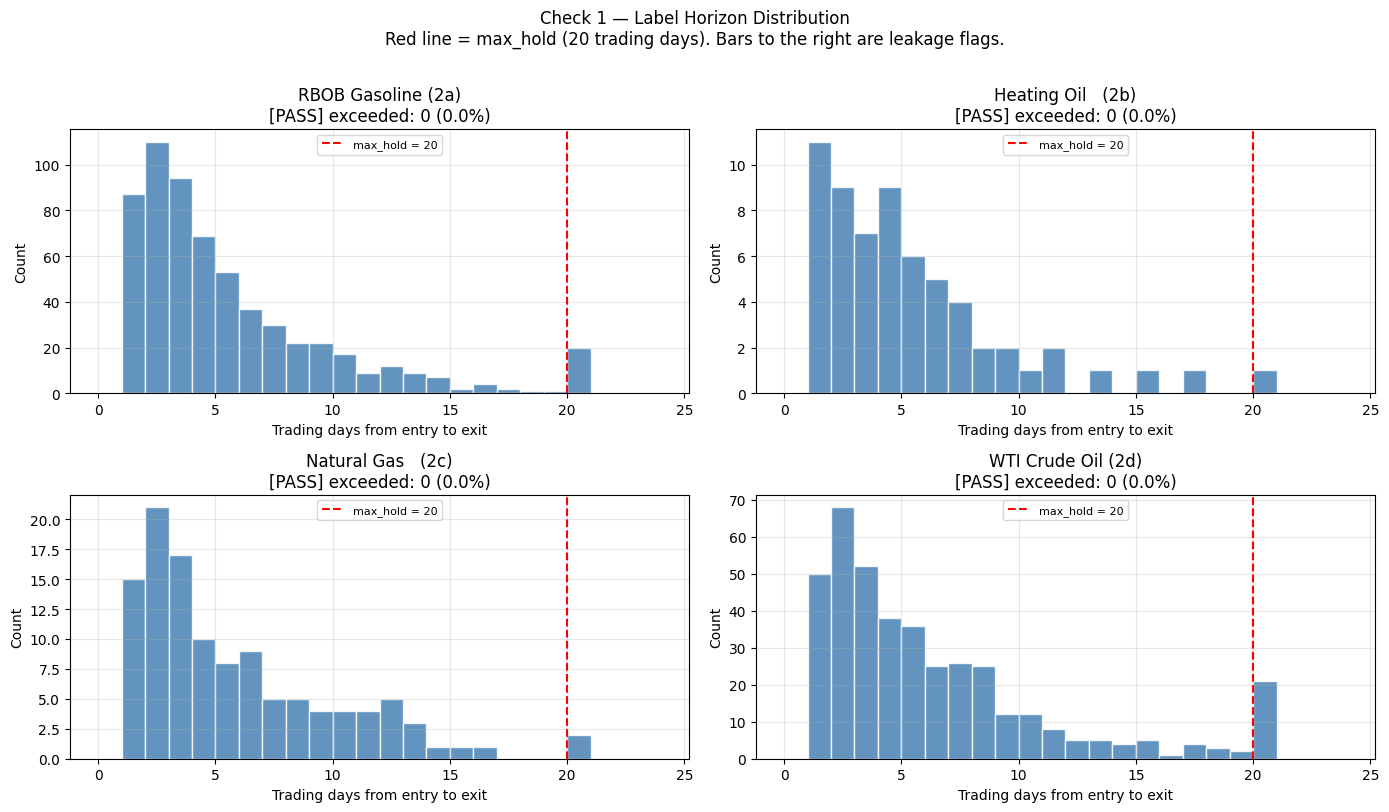

In [8]:
# ── Plot label horizon distributions ────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (inst, label) in zip(axes, INSTRUMENTS.items()):
    res = leakage_results.get(inst, {})
    if "labels_df" not in res:
        ax.set_title(f"{label}\n(no data)")
        continue

    df = res["labels_df"]
    ax.hist(df["trading_days"], bins=range(0, TRIPLE_BARRIER_MAX_HOLD + 5),
            color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(TRIPLE_BARRIER_MAX_HOLD, color="red", lw=1.5, linestyle="--",
               label=f"max_hold = {TRIPLE_BARRIER_MAX_HOLD}")
    ax.set_title(f"{label}\n[{res['status']}] exceeded: {res['n_exceeded']} "
                 f"({res['pct_exceeded']:.1f}%)")
    ax.set_xlabel("Trading days from entry to exit")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Check 1 — Label Horizon Distribution\n"
             "Red line = max_hold (20 trading days). Bars to the right are leakage flags.",
             y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# ── Check that features are shifted (no same-day return look-ahead) ──────────
#
# The pipeline does: result[feat_cols] = result.groupby("instrument")[feat_cols].shift(1)
# So features[t] should reflect information known at end-of-day t-1.
# If logret_1d at row t equals the actual t-day return, the shift was skipped.

print("Checking that logret_1d is shifted (features[t] ≠ raw return at t)...")
print()

for inst, label in INSTRUMENTS.items():
    inst_feat  = features[features["instrument"] == inst].set_index("date").sort_index()
    inst_ohlcv = (ohlcv[ohlcv["instrument"] == inst]
                  .set_index("date")["close"]
                  .sort_index())

    if "logret_1d" not in inst_feat.columns:
        print(f"  {inst}: logret_1d not found — skipping")
        continue

    # Raw return at each date t
    raw_ret = np.log(inst_ohlcv / inst_ohlcv.shift(1))

    # Feature value (should be yesterday's return if shifted correctly)
    feat_ret = inst_feat["logret_1d"]

    # Align on common dates
    common = feat_ret.index.intersection(raw_ret.index)
    raw_ret_aligned  = raw_ret.loc[common]
    feat_ret_aligned = feat_ret.loc[common]

    # Count exact matches (within floating-point tolerance)
    same_day_matches = np.isclose(feat_ret_aligned, raw_ret_aligned,
                                  atol=1e-10, equal_nan=False).sum()
    pct_same = 100 * same_day_matches / len(common)

    # A perfectly shifted feature should have ~0 same-day matches.
    # (Some coincidental equality is possible but should be negligible.)
    status = "PASS" if pct_same < 1.0 else "FAIL"

    print(f"  [{status}] {label} ({inst})")
    print(f"         Same-day logret_1d matches: {same_day_matches} / {len(common)} ({pct_same:.2f}%)")

Checking that logret_1d is shifted (features[t] ≠ raw return at t)...

  [PASS] RBOB Gasoline (2a) (rb1s)
         Same-day logret_1d matches: 0 / 628 (0.00%)
  [PASS] Heating Oil   (2b) (ho1s)
         Same-day logret_1d matches: 0 / 628 (0.00%)
  [PASS] Natural Gas   (2c) (ng1s)
         Same-day logret_1d matches: 0 / 628 (0.00%)
  [PASS] WTI Crude Oil (2d) (cl1s)
         Same-day logret_1d matches: 0 / 628 (0.00%)


---
## Check 2 — Class Imbalance

**What we check:**

The meta-label is binary: 1 = profit-take barrier hit first, 0 = stop-loss or time
barrier hit first. If one class dominates, classifiers default to predicting the
majority class and AUC becomes misleading.

We check the **minority class percentage** (whichever of 0 or 1 appears less often)
for each instrument and compare against two thresholds:

- `WARN`: minority class < 35 % (the main notebooks already use `class_weight` or
  `scale_pos_weight` to compensate, so mild imbalance is expected and handled)
- `FAIL`: minority class < 20 % (severe enough that even reweighting may not rescue
  calibration on this sample size)

We also show the raw counts and the win-rate (fraction of trades that hit the
profit-take barrier), since that is the number reported in the notebooks.

In [10]:
# ── Run Check 2 for every instrument ────────────────────────────────────────

imbalance_results = {}

for inst, label in INSTRUMENTS.items():

    inst_feat  = features[features["instrument"] == inst].set_index("date").sort_index()
    inst_ohlcv = (ohlcv[ohlcv["instrument"] == inst]
                  .set_index("date")["close"]
                  .sort_index())

    signals = inst_feat["primary_signal"].dropna()

    labels_df = reconstruct_triple_barrier_labels(
        close    = inst_ohlcv,
        signals  = signals,
        pt_sl    = [1.5, 1.5],
        max_hold = TRIPLE_BARRIER_MAX_HOLD,
    )

    if labels_df.empty:
        imbalance_results[inst] = {"status": "WARN", "detail": "No labels"}
        continue

    counts   = labels_df["meta_label"].value_counts().sort_index()
    n_total  = len(labels_df)
    n_pos    = int(counts.get(1, 0))
    n_neg    = int(counts.get(0, 0))
    win_rate = 100 * n_pos / n_total
    minority_pct = min(win_rate, 100 - win_rate)

    if minority_pct >= IMBALANCE_WARN_PCT:
        status = "PASS"
    elif minority_pct >= IMBALANCE_FAIL_PCT:
        status = "WARN"
    else:
        status = "FAIL"

    imbalance_results[inst] = {
        "status":       status,
        "n_total":      n_total,
        "n_pos":        n_pos,
        "n_neg":        n_neg,
        "win_rate":     round(win_rate, 1),
        "minority_pct": round(minority_pct, 1),
        "labels_df":    labels_df,
    }

    print(f"[{status:4s}] {label} ({inst})")
    print(f"       Total labels: {n_total}  |  Win (1): {n_pos}  |  Loss (0): {n_neg}")
    print(f"       Win rate: {win_rate:.1f}%  |  Minority class: {minority_pct:.1f}%")
    print()

[PASS] RBOB Gasoline (2a) (rb1s)
       Total labels: 608  |  Win (1): 303  |  Loss (0): 305
       Win rate: 49.8%  |  Minority class: 49.8%

[PASS] Heating Oil   (2b) (ho1s)
       Total labels: 62  |  Win (1): 38  |  Loss (0): 24
       Win rate: 61.3%  |  Minority class: 38.7%

[PASS] Natural Gas   (2c) (ng1s)
       Total labels: 115  |  Win (1): 57  |  Loss (0): 58
       Win rate: 49.6%  |  Minority class: 49.6%



[WARN] WTI Crude Oil (2d) (cl1s)
       Total labels: 402  |  Win (1): 268  |  Loss (0): 134
       Win rate: 66.7%  |  Minority class: 33.3%



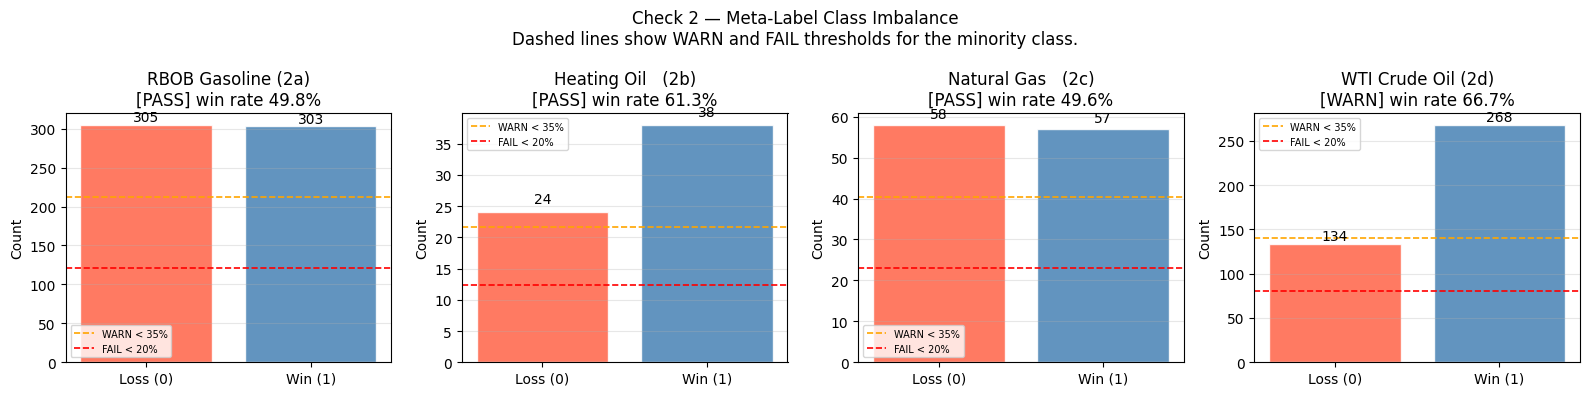

In [11]:
# ── Plot class distributions ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (inst, label) in zip(axes, INSTRUMENTS.items()):
    res = imbalance_results.get(inst, {})
    if "labels_df" not in res:
        ax.set_title(f"{label}\n(no data)")
        continue

    n_pos = res["n_pos"]
    n_neg = res["n_neg"]
    colors = ["tomato", "steelblue"]

    bars = ax.bar(["Loss (0)", "Win (1)"], [n_neg, n_pos], color=colors, alpha=0.85,
                  edgecolor="white")
    for bar, n in zip(bars, [n_neg, n_pos]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(n), ha="center", va="bottom", fontsize=10)

    ax.axhline(res["n_total"] * IMBALANCE_WARN_PCT / 100, color="orange",
               linestyle="--", lw=1.2, label=f"WARN < {IMBALANCE_WARN_PCT}%")
    ax.axhline(res["n_total"] * IMBALANCE_FAIL_PCT / 100, color="red",
               linestyle="--", lw=1.2, label=f"FAIL < {IMBALANCE_FAIL_PCT}%")

    ax.set_title(f"{INSTRUMENTS[inst]}\n[{res['status']}] win rate {res['win_rate']}%")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Check 2 — Meta-Label Class Imbalance\n"
             "Dashed lines show WARN and FAIL thresholds for the minority class.")
plt.tight_layout()
plt.show()

---
## Check 3 — Outliers

**What we check:**

Extreme feature values corrupt `RobustScaler` outputs, distort PCA loadings,
and dominate distance-based models. We flag features where any value lies more than
`OUTLIER_IQR_MULTIPLIER × IQR` from the median (a robust, fat-tail-aware test).

We run this on the post-signal-start window (from `SIGNAL_START` onward) because that
is the window the models actually see. The full history is checked separately to
understand whether outliers are ancient or recent.

**Verdict logic per instrument:**
- `PASS` — fewer than 5% of feature columns contain at least one outlier.
- `WARN` — 5–15% of columns contain outliers.
- `FAIL` — more than 15% of columns contain outliers, suggesting the scaler will
  struggle and model inputs may be dominated by a few extreme days.

In [12]:
def flag_outliers(df: pd.DataFrame,
                  cols: list,
                  iqr_mult: float = OUTLIER_IQR_MULTIPLIER) -> pd.DataFrame:
    """
    For each column in cols, count values beyond iqr_mult × IQR from the median.

    Returns a summary DataFrame with one row per column that has at least one outlier.
    """
    rows = []
    for col in cols:
        s = df[col].dropna()
        if len(s) < 10:
            continue
        q25, q75 = s.quantile(0.25), s.quantile(0.75)
        iqr = q75 - q25
        if iqr == 0:
            continue
        lo = q25 - iqr_mult * iqr
        hi = q75 + iqr_mult * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        if n_out > 0:
            rows.append({
                "feature":    col,
                "n_outliers": int(n_out),
                "pct":        round(100 * n_out / len(s), 2),
                "lower_fence": round(lo, 4),
                "upper_fence": round(hi, 4),
                "min_val":    round(s.min(), 4),
                "max_val":    round(s.max(), 4),
            })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

In [13]:
# ── Run Check 3 for every instrument ────────────────────────────────────────

OUTLIER_WARN_PCT = 5    # % of feature columns with at least one outlier
OUTLIER_FAIL_PCT = 15

outlier_results = {}

for inst, label in INSTRUMENTS.items():

    inst_feat = (features[features["instrument"] == inst]
                 .set_index("date")
                 .sort_index())

    # Limit to the signal window that the models actually use
    post_start = inst_feat.loc[SIGNAL_START:]

    out_df = flag_outliers(post_start, feature_cols)

    n_cols        = len([c for c in feature_cols if post_start[c].notna().any()])
    n_flagged     = len(out_df)
    pct_flagged   = 100 * n_flagged / n_cols if n_cols > 0 else 0

    if pct_flagged <= OUTLIER_WARN_PCT:
        status = "PASS"
    elif pct_flagged <= OUTLIER_FAIL_PCT:
        status = "WARN"
    else:
        status = "FAIL"

    outlier_results[inst] = {
        "status":      status,
        "n_cols":      n_cols,
        "n_flagged":   n_flagged,
        "pct_flagged": round(pct_flagged, 1),
        "detail":      out_df,
    }

    print(f"[{status:4s}] {label} ({inst})")
    print(f"       Features checked: {n_cols}  |  Columns with outliers: {n_flagged} "
          f"({pct_flagged:.1f}%)")
    if n_flagged > 0:
        top = out_df.head(5)
        print(f"       Top outlier features (by % of rows):")
        for _, row in top.iterrows():
            print(f"         {row['feature']:<30} {row['n_outliers']:>4} rows "
                  f"({row['pct']:.2f}%)  range [{row['min_val']}, {row['max_val']}]")
    print()

[PASS] RBOB Gasoline (2a) (rb1s)
       Features checked: 60  |  Columns with outliers: 2 (3.3%)
       Top outlier features (by % of rows):
         gmm_resp_high_vol                35 rows (15.84%)  range [0.0, 0.6551]
         oi_change_5d                      1 rows (0.45%)  range [-0.4552, 2.3101]

[WARN] Heating Oil   (2b) (ho1s)
       Features checked: 60  |  Columns with outliers: 4 (6.7%)
       Top outlier features (by % of rows):
         gmm_resp_high_vol                41 rows (18.55%)  range [0.0, 1.0]
         ret_1d                            1 rows (0.45%)  range [-0.2193, 0.1315]
         logret_1d                         1 rows (0.45%)  range [-0.2475, 0.1236]
         ret_5d                            1 rows (0.45%)  range [-0.3816, 0.3423]

[WARN] Natural Gas   (2c) (ng1s)
       Features checked: 60  |  Columns with outliers: 5 (8.3%)
       Top outlier features (by % of rows):
         hmm_filt_calm                    44 rows (19.91%)  range [0.0, 1.0]
         

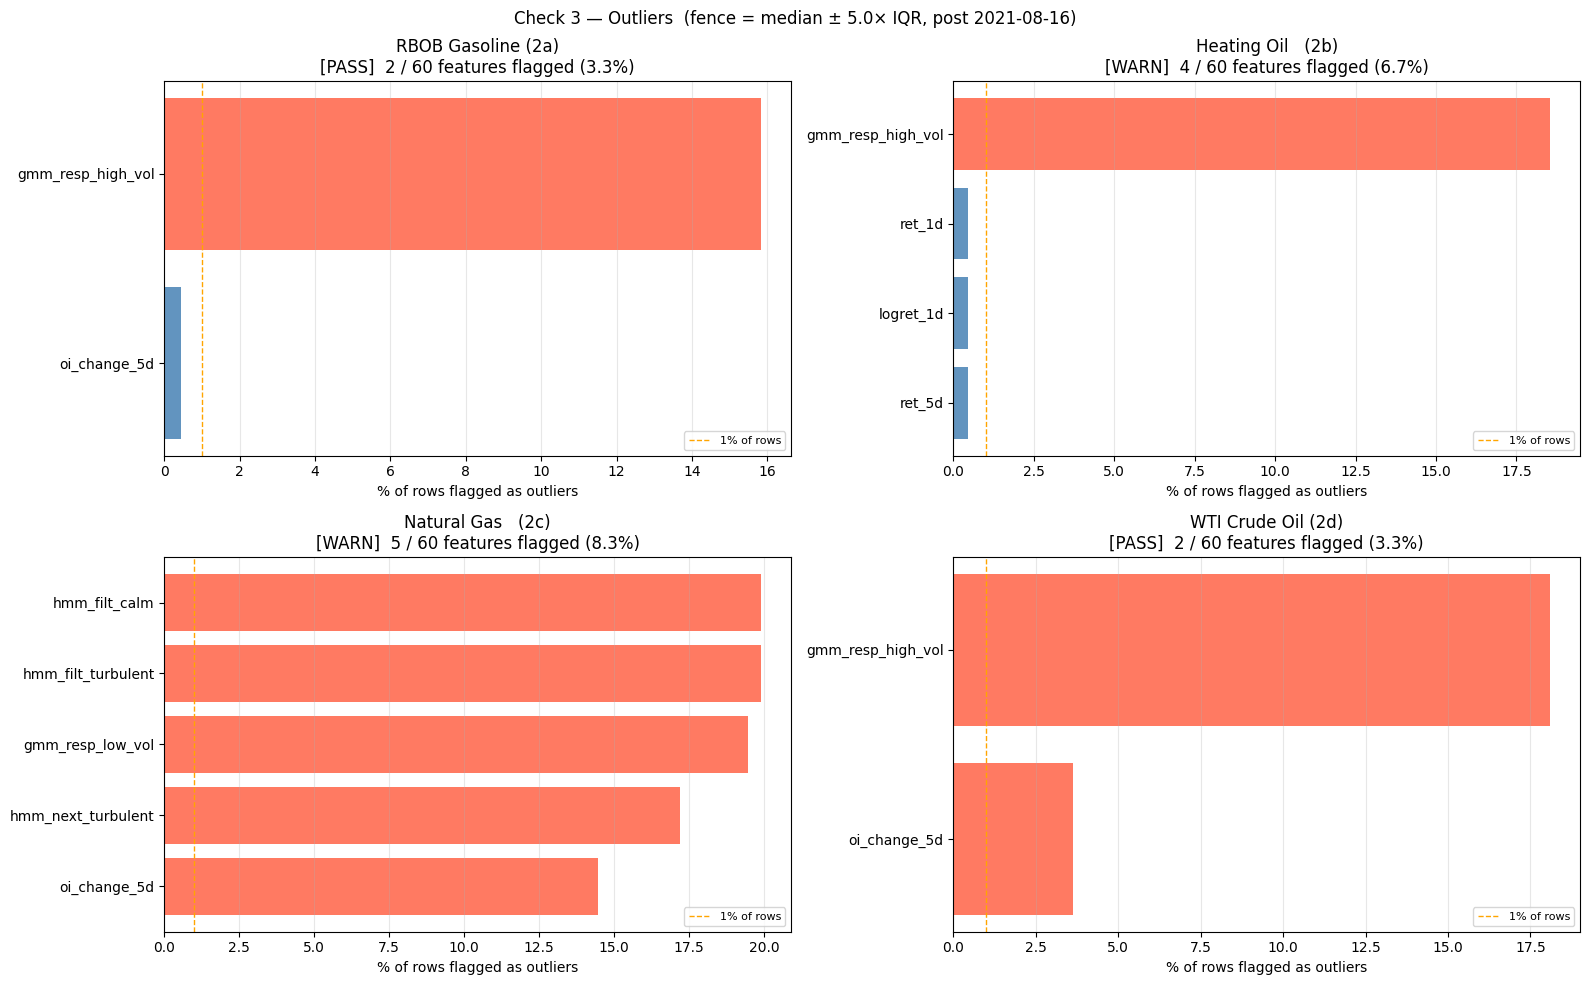

In [14]:
# ── Plot: outlier count per feature, top-10 worst per instrument ──────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (inst, label) in zip(axes, INSTRUMENTS.items()):
    res = outlier_results.get(inst, {})
    df  = res.get("detail", pd.DataFrame())

    if df.empty:
        ax.text(0.5, 0.5, "No outliers detected", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="green")
        ax.set_title(f"{label}\n[{res.get('status','?')}]")
        continue

    top = df.head(10)
    colors = ["tomato" if p > 1 else "steelblue" for p in top["pct"]]
    ax.barh(top["feature"][::-1], top["pct"][::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(1.0, color="orange", linestyle="--", lw=1, label="1% of rows")
    ax.set_xlabel("% of rows flagged as outliers")
    ax.set_title(f"{label}\n[{res['status']}]  {res['n_flagged']} / {res['n_cols']} "
                 f"features flagged ({res['pct_flagged']}%)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle(f"Check 3 — Outliers  (fence = median ± {OUTLIER_IQR_MULTIPLIER}× IQR, "
             f"post {SIGNAL_START.date()})")
plt.tight_layout()
plt.show()

Worst outlier feature per instrument (time-series context):



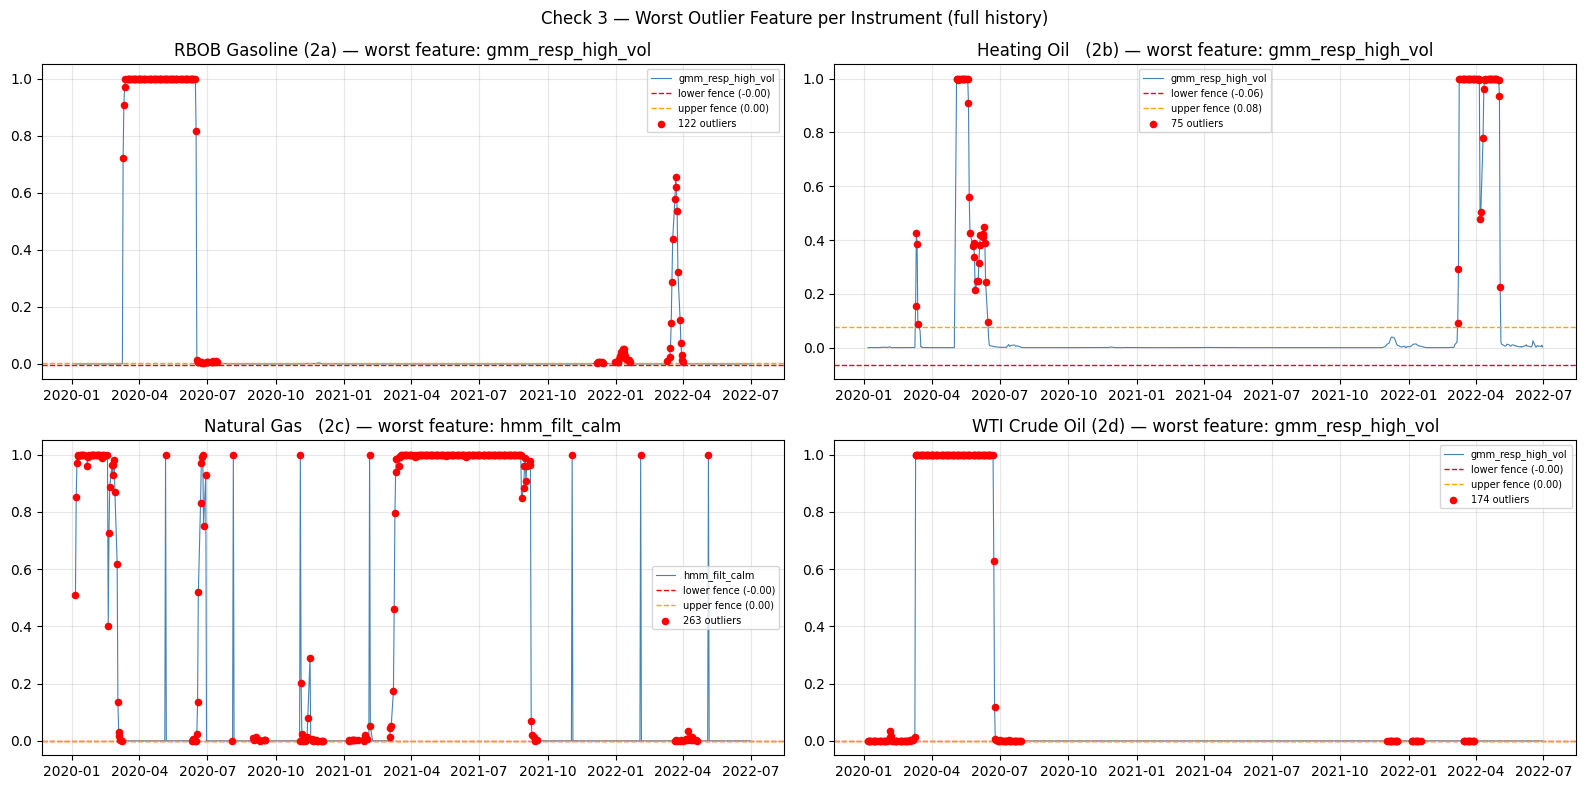

In [15]:
# ── Detailed view: worst single outlier per instrument ───────────────────────
#
# For the single most-outlier-affected feature per instrument, show a time-series
# plot so we can see *when* the extreme values occurred (e.g. COVID crash, OPEC shock).

print("Worst outlier feature per instrument (time-series context):")
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, (inst, label) in zip(axes, INSTRUMENTS.items()):
    res = outlier_results.get(inst, {})
    df  = res.get("detail", pd.DataFrame())

    if df.empty:
        ax.set_title(f"{label} — no outliers")
        continue

    worst_feat = df.iloc[0]["feature"]
    lo = df.iloc[0]["lower_fence"]
    hi = df.iloc[0]["upper_fence"]

    inst_feat = (features[features["instrument"] == inst]
                 .set_index("date")[worst_feat]
                 .sort_index())

    ax.plot(inst_feat.index, inst_feat.values, lw=0.8, color="steelblue", label=worst_feat)
    ax.axhline(lo, color="red",    linestyle="--", lw=1, label=f"lower fence ({lo:.2f})")
    ax.axhline(hi, color="orange", linestyle="--", lw=1, label=f"upper fence ({hi:.2f})")

    # Shade the outlier points
    mask = (inst_feat < lo) | (inst_feat > hi)
    ax.scatter(inst_feat.index[mask], inst_feat.values[mask],
               color="red", s=20, zorder=5, label=f"{mask.sum()} outliers")

    ax.set_title(f"{label} — worst feature: {worst_feat}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Check 3 — Worst Outlier Feature per Instrument (full history)")
plt.tight_layout()
plt.show()

---
## Check 4 — Stationarity

**What we check:**

Most classifiers (logistic regression, random forest, XGBoost) implicitly assume that
the distribution of features is stable over time. Non-stationary features — ones with
a trending mean or variance — violate this assumption and lead to train/test distribution
shift even when there is no explicit look-ahead.

We test each feature with two complementary tests:

| Test | Null hypothesis | Flag when |
|------|----------------|-----------|
| **ADF** (Augmented Dickey-Fuller) | Series has a unit root (non-stationary) | Fail to reject at 5% → non-stationary |
| **KPSS** | Series is stationary | Reject at 5% → non-stationary |

A feature is called **non-stationary** if *both* tests agree: ADF p-value > 0.05 AND
KPSS p-value < 0.05. Requiring agreement between two tests in opposite directions reduces
false positives from the fat-tailed financial data.

We focus on the **return and raw level features** (not derived ratios or z-scores, which
are already mean-reverting by construction). We run on the signal window post `SIGNAL_START`.

**Verdict logic per instrument:**
- `PASS` — fewer than 15% of tested features are non-stationary.
- `WARN` — 15–30% are non-stationary.
- `FAIL` — more than 30% are non-stationary.

In [16]:
def test_stationarity(series: pd.Series,
                      significance: float = 0.05) -> dict:
    """
    Run ADF and KPSS on a series and return a result dict.

    A feature is flagged as non-stationary when:
      - ADF p-value > significance  (fail to reject unit-root null)
      - KPSS p-value < significance (reject stationarity null)

    Requiring both to agree reduces false positives.
    """
    s = series.dropna()
    if len(s) < 30:
        return {"non_stationary": None, "adf_pval": None, "kpss_pval": None}

    try:
        adf_pval = adfuller(s, autolag="AIC")[1]
    except Exception:
        adf_pval = np.nan

    try:
        kpss_pval = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_pval = np.nan

    adf_says_nonstat  = (adf_pval  > significance) if pd.notna(adf_pval)  else None
    kpss_says_nonstat = (kpss_pval < significance) if pd.notna(kpss_pval) else None

    # Both tests must agree for us to call it non-stationary (conservative)
    if adf_says_nonstat is None or kpss_says_nonstat is None:
        non_stationary = None
    else:
        non_stationary = adf_says_nonstat and kpss_says_nonstat

    return {
        "non_stationary": non_stationary,
        "adf_pval":       round(adf_pval,  4) if pd.notna(adf_pval)  else None,
        "kpss_pval":      round(kpss_pval, 4) if pd.notna(kpss_pval) else None,
    }

In [17]:
# ── Run Check 4 for every instrument ────────────────────────────────────────
#
# We test all feature columns. The KPSS p-value is often reported as interpolated
# (e.g. "p-value is greater than 0.1") when it lies outside the table bounds — this
# is expected and does not affect the verdict.

stationarity_results = {}

for inst, label in INSTRUMENTS.items():

    inst_feat = (features[features["instrument"] == inst]
                 .set_index("date")
                 .sort_index()
                 .loc[SIGNAL_START:])

    rows = []
    for col in feature_cols:
        if col not in inst_feat.columns:
            continue
        if inst_feat[col].notna().sum() < 30:
            continue
        result = test_stationarity(inst_feat[col])
        result["feature"] = col
        rows.append(result)

    if not rows:
        stationarity_results[inst] = {"status": "WARN", "detail": "No features tested"}
        continue

    stat_df = pd.DataFrame(rows)

    # Only count features where we have a clear answer
    decided = stat_df[stat_df["non_stationary"].notna()]
    n_tested      = len(decided)
    n_nonstat     = int(decided["non_stationary"].sum())
    pct_nonstat   = 100 * n_nonstat / n_tested if n_tested > 0 else 0

    if pct_nonstat <= 15:
        status = "PASS"
    elif pct_nonstat <= STATIONARITY_FAIL_FRACTION * 100:
        status = "WARN"
    else:
        status = "FAIL"

    stationarity_results[inst] = {
        "status":       status,
        "n_tested":     n_tested,
        "n_nonstat":    n_nonstat,
        "pct_nonstat":  round(pct_nonstat, 1),
        "detail":       stat_df,
    }

    print(f"[{status:4s}] {label} ({inst})")
    print(f"       Features tested: {n_tested}  |  Non-stationary: {n_nonstat} "
          f"({pct_nonstat:.1f}%)")

    if n_nonstat > 0:
        flagged = decided[decided["non_stationary"]].sort_values("adf_pval", ascending=False)
        print("       Non-stationary features (ADF p-val, KPSS p-val):")
        for _, row in flagged.head(10).iterrows():
            print(f"         {row['feature']:<30}  ADF={row['adf_pval']}  KPSS={row['kpss_pval']}")
    print()

[FAIL] RBOB Gasoline (2a) (rb1s)
       Features tested: 60  |  Non-stationary: 19 (31.7%)
       Non-stationary features (ADF p-val, KPSS p-val):
         month_cos                       ADF=0.9165  KPSS=0.01
         ho_cl_spread                    ADF=0.8687  KPSS=0.01
         atr_14                          ADF=0.6357  KPSS=0.01
         month_sin                       ADF=0.6168  KPSS=0.01
         winter_indicator                ADF=0.5518  KPSS=0.0362
         rb_cl_spread                    ADF=0.471  KPSS=0.01
         driving_season                  ADF=0.4537  KPSS=0.0132
         ret_60d                         ADF=0.3693  KPSS=0.01
         vol_60d                         ADF=0.3357  KPSS=0.01
         runup_from_60d_low              ADF=0.2253  KPSS=0.01

[FAIL] Heating Oil   (2b) (ho1s)
       Features tested: 60  |  Non-stationary: 28 (46.7%)
       Non-stationary features (ADF p-val, KPSS p-val):
         hmm_regime_age                  ADF=0.9704  KPSS=0.01
         

[WARN] Natural Gas   (2c) (ng1s)
       Features tested: 60  |  Non-stationary: 16 (26.7%)
       Non-stationary features (ADF p-val, KPSS p-val):
         primary_signal_streak           ADF=0.9849  KPSS=0.01
         month_cos                       ADF=0.9165  KPSS=0.01
         ho_cl_spread                    ADF=0.8687  KPSS=0.01
         atr_14                          ADF=0.6222  KPSS=0.01
         month_sin                       ADF=0.6168  KPSS=0.01
         winter_indicator                ADF=0.5518  KPSS=0.0362
         ret_60d                         ADF=0.5227  KPSS=0.0323
         trend_tstat_60                  ADF=0.5208  KPSS=0.0429
         macd_signal                     ADF=0.4756  KPSS=0.0194
         rb_cl_spread                    ADF=0.471  KPSS=0.01

[FAIL] WTI Crude Oil (2d) (cl1s)
       Features tested: 60  |  Non-stationary: 20 (33.3%)
       Non-stationary features (ADF p-val, KPSS p-val):
         month_cos                       ADF=0.9165  KPSS=0.01
     

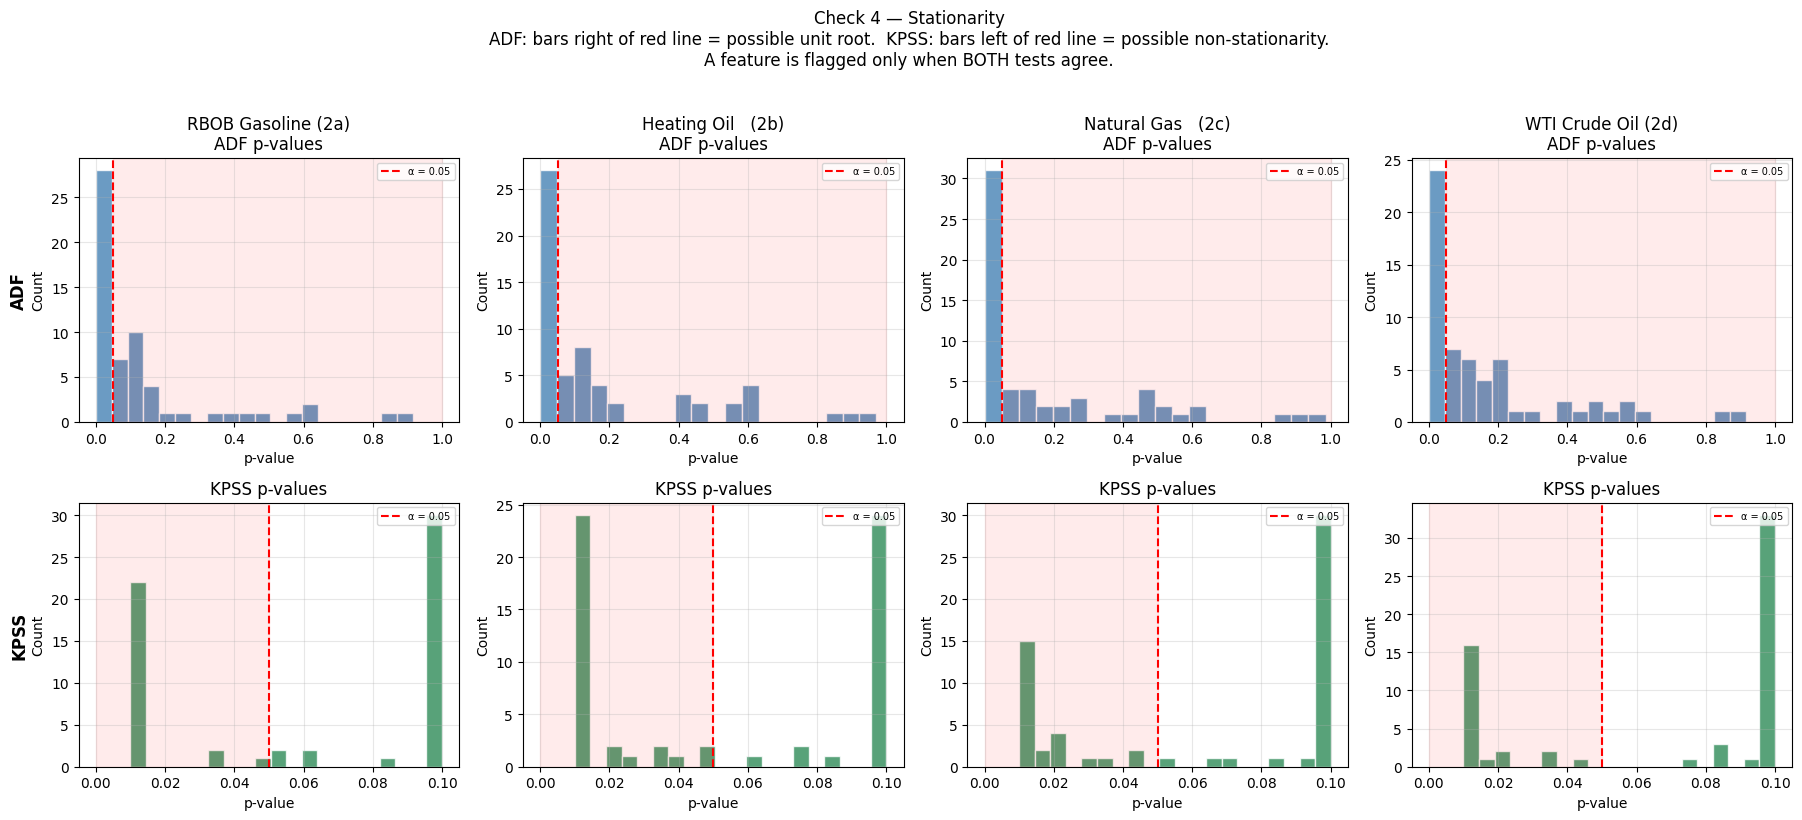

In [18]:
# ── Plot p-value distributions to see overall stationarity health ─────────────

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col_idx, (inst, label) in enumerate(INSTRUMENTS.items()):
    res = stationarity_results.get(inst, {})
    df  = res.get("detail", pd.DataFrame())

    ax_adf  = axes[0, col_idx]
    ax_kpss = axes[1, col_idx]

    if df.empty or "adf_pval" not in df.columns:
        ax_adf.set_title(f"{label}\nno data")
        ax_kpss.set_title("no data")
        continue

    adf_vals  = df["adf_pval"].dropna()
    kpss_vals = df["kpss_pval"].dropna()

    ax_adf.hist(adf_vals, bins=20, color="steelblue", alpha=0.8, edgecolor="white")
    ax_adf.axvline(0.05, color="red", linestyle="--", lw=1.5, label="α = 0.05")
    ax_adf.set_title(f"{label}\nADF p-values")
    ax_adf.set_xlabel("p-value")
    ax_adf.set_ylabel("Count")
    ax_adf.legend(fontsize=7)
    ax_adf.grid(True, alpha=0.3)
    # Values ABOVE 0.05 = non-stationary (shaded)
    ax_adf.axvspan(0.05, 1.0, color="red", alpha=0.08, label="non-stat region")

    ax_kpss.hist(kpss_vals, bins=20, color="seagreen", alpha=0.8, edgecolor="white")
    ax_kpss.axvline(0.05, color="red", linestyle="--", lw=1.5, label="α = 0.05")
    ax_kpss.set_title(f"KPSS p-values")
    ax_kpss.set_xlabel("p-value")
    ax_kpss.set_ylabel("Count")
    ax_kpss.legend(fontsize=7)
    ax_kpss.grid(True, alpha=0.3)
    # Values BELOW 0.05 = non-stationary (shaded)
    ax_kpss.axvspan(0.0, 0.05, color="red", alpha=0.08, label="non-stat region")

axes[0, 0].text(-0.18, 0.5, "ADF", transform=axes[0, 0].transAxes,
                fontsize=12, fontweight="bold", va="center", rotation=90)
axes[1, 0].text(-0.18, 0.5, "KPSS", transform=axes[1, 0].transAxes,
                fontsize=12, fontweight="bold", va="center", rotation=90)

plt.suptitle(
    "Check 4 — Stationarity\n"
    "ADF: bars right of red line = possible unit root.  "
    "KPSS: bars left of red line = possible non-stationarity.\n"
    "A feature is flagged only when BOTH tests agree.",
    y=1.02
)
plt.tight_layout()
plt.show()

---
## Summary Scorecard

The table below collects all verdicts in one place. Each cell shows the status
(`PASS` / `WARN` / `FAIL`) for each instrument × check combination.

- **PASS** — no issue detected; proceed with confidence.
- **WARN** — marginal; review the detail above but the pipeline can continue.
- **FAIL** — action required before trusting model outputs for this instrument.

In [19]:
# ── Build summary table ──────────────────────────────────────────────────────

STATUS_EMOJI = {"PASS": "✅ PASS", "WARN": "⚠️  WARN", "FAIL": "❌ FAIL", None: "—"}

rows = []
for inst, label in INSTRUMENTS.items():
    rows.append({
        "Instrument":          label,
        "Check 1 · Leakage":   STATUS_EMOJI.get(leakage_results.get(inst, {}).get("status")),
        "Check 2 · Imbalance": STATUS_EMOJI.get(imbalance_results.get(inst, {}).get("status")),
        "Check 3 · Outliers":  STATUS_EMOJI.get(outlier_results.get(inst, {}).get("status")),
        "Check 4 · Stationarity": STATUS_EMOJI.get(stationarity_results.get(inst, {}).get("status")),
    })

summary = pd.DataFrame(rows).set_index("Instrument")
print("=" * 80)
print("SANITY CHECK SCORECARD")
print("=" * 80)
print(summary.to_string())
print("=" * 80)

SANITY CHECK SCORECARD
                   Check 1 · Leakage Check 2 · Imbalance Check 3 · Outliers Check 4 · Stationarity
Instrument                                                                                        
RBOB Gasoline (2a)            ✅ PASS              ✅ PASS             ✅ PASS                 ❌ FAIL
Heating Oil   (2b)            ✅ PASS              ✅ PASS           ⚠️  WARN                 ❌ FAIL
Natural Gas   (2c)            ✅ PASS              ✅ PASS           ⚠️  WARN               ⚠️  WARN
WTI Crude Oil (2d)            ✅ PASS            ⚠️  WARN             ✅ PASS                 ❌ FAIL


In [20]:
# ── Key numbers behind each verdict ─────────────────────────────────────────

print("\nKey numbers behind each verdict")
print("-" * 80)
for inst, label in INSTRUMENTS.items():
    print(f"\n{label} ({inst})")

    lk = leakage_results.get(inst, {})
    if "pct_exceeded" in lk:
        print(f"  Leakage    : {lk['n_exceeded']} of {lk['n_labels']} labels exceed "
              f"max_hold ({lk['pct_exceeded']:.2f}%); "
              f"max trading-day horizon = {lk['max_td']}")

    im = imbalance_results.get(inst, {})
    if "win_rate" in im:
        print(f"  Imbalance  : win rate = {im['win_rate']:.1f}%  "
              f"(minority class = {im['minority_pct']:.1f}%)")

    ol = outlier_results.get(inst, {})
    if "n_flagged" in ol:
        print(f"  Outliers   : {ol['n_flagged']} of {ol['n_cols']} features have "
              f"outliers beyond {OUTLIER_IQR_MULTIPLIER}× IQR ({ol['pct_flagged']:.1f}%)")

    st = stationarity_results.get(inst, {})
    if "n_nonstat" in st:
        print(f"  Stationarity: {st['n_nonstat']} of {st['n_tested']} features "
              f"non-stationary by ADF+KPSS agreement ({st['pct_nonstat']:.1f}%)")


Key numbers behind each verdict
--------------------------------------------------------------------------------

RBOB Gasoline (2a) (rb1s)
  Leakage    : 0 of 608 labels exceed max_hold (0.00%); max trading-day horizon = 20
  Imbalance  : win rate = 49.8%  (minority class = 49.8%)
  Outliers   : 2 of 60 features have outliers beyond 5.0× IQR (3.3%)
  Stationarity: 19 of 60 features non-stationary by ADF+KPSS agreement (31.7%)

Heating Oil   (2b) (ho1s)
  Leakage    : 0 of 62 labels exceed max_hold (0.00%); max trading-day horizon = 20
  Imbalance  : win rate = 61.3%  (minority class = 38.7%)
  Outliers   : 4 of 60 features have outliers beyond 5.0× IQR (6.7%)
  Stationarity: 28 of 60 features non-stationary by ADF+KPSS agreement (46.7%)

Natural Gas   (2c) (ng1s)
  Leakage    : 0 of 115 labels exceed max_hold (0.00%); max trading-day horizon = 20
  Imbalance  : win rate = 49.6%  (minority class = 49.6%)
  Outliers   : 5 of 60 features have outliers beyond 5.0× IQR (8.3%)
  Stationari

---
### Interpreting the Results

**Check 1 — Leakage:**
Any label that exits more than 20 trading days after entry was formed using data
the model could not have seen at training time. A small number of edge cases at
exactly the time barrier are acceptable (rounding); more than 1% is a pipeline bug.

**Check 2 — Imbalance:**
The main notebooks compensate for imbalance via `class_weight='balanced'`
(logistic regression, random forest) and `scale_pos_weight` (XGBoost). A mild
imbalance (35–50% minority) is therefore acceptable; below 20% means even
reweighting may not rescue calibration on this small sample and the triple-barrier
parameters should be reconsidered.

**Check 3 — Outliers:**
`RobustScaler` is deliberately used throughout the pipeline precisely because energy
markets produce fat tails. Outliers flagged here are informational: if the same dates
keep appearing across instruments (e.g. April 2020 WTI negative print), that is a
known structural break and not a bug. If outliers are concentrated in derived features
(not raw returns), there may be a numerical issue in the pipeline.

**Check 4 — Stationarity:**
Return-derived features (log returns, RSI, z-scores) are expected to be stationary.
Raw price levels are expected to be non-stationary — but we do not feed raw levels
into the model. If a z-score or ratio feature shows up as non-stationary, the rolling
window may be too long relative to the available history, or the feature may be
picking up a genuine structural break in the market microstructure.

## Check 6 — Tail-signal coverage post-decoupling

The per-instrument labellers in 2a/2b/2c/2d now skip signals that have no full
`max_hold = 20` forward window — i.e. the last ~20 signalled days at the data
end have no triple-barrier label. The export cells decouple prediction from
labelling, so those same tail signals **do** still receive a model probability
in the deliverable CSV.

This check verifies the decoupling end-to-end for each instrument:

- **`n_signalled`** — non-zero primary signals in the full data window
- **`n_labelled`** — labels produced by the data-end-aware labeller
- **`n_tail_unlabelled`** — `n_signalled - n_labelled`; this is the count of
  signalled days at the data end that have no label but **should still appear
  in the predictions CSV with a real probability**.

On the released window (data ends 2022-06-30) the tail count should be
approximately the number of signalled days inside the last 20 trading days of
June 2022 — i.e. somewhere between 1 and 20 depending on signal density.

On the hidden H2 2022 rerun (data ends 2022-12-31) the same logic applies to
the last 20 trading days of December 2022; if the deliverable window is also
extended to cover that period, those tail signals must appear in the predictions
CSV with real probabilities rather than trailing-ffill values.


In [21]:
# ── Check 6 — Tail-signal coverage post-decoupling ──────────────────────────
tail_results = {}

for inst, label in INSTRUMENTS.items():
    inst_feat  = features[features["instrument"] == inst].set_index("date").sort_index()
    inst_ohlcv = (ohlcv[ohlcv["instrument"] == inst]
                  .set_index("date")["close"]
                  .sort_index())

    signals = inst_feat["primary_signal"].dropna()
    n_signalled = int((signals != 0).sum())

    labels_df = reconstruct_triple_barrier_labels(
        close    = inst_ohlcv,
        signals  = signals,
        pt_sl    = [1.5, 1.5],
        max_hold = TRIPLE_BARRIER_MAX_HOLD,
    )
    n_labelled = 0 if labels_df.empty else len(labels_df)
    n_tail_unlabelled = n_signalled - n_labelled

    # The tail-bound is max_hold trading days. Strictly fewer signals than that
    # may fire inside the last max_hold bars (sparse signal regions), so we
    # accept any tail count in [0, max_hold].
    if 0 <= n_tail_unlabelled <= TRIPLE_BARRIER_MAX_HOLD:
        status = "PASS"
    else:
        status = "FAIL"

    tail_results[inst] = {
        "status":            status,
        "n_signalled":       n_signalled,
        "n_labelled":        n_labelled,
        "n_tail_unlabelled": n_tail_unlabelled,
    }

    print(f"[{status:4s}] {label} ({inst})")
    print(f"       signalled:        {n_signalled}")
    print(f"       labelled:         {n_labelled}")
    print(f"       tail-unlabelled:  {n_tail_unlabelled}  "
          f"(should be in [0, {TRIPLE_BARRIER_MAX_HOLD}])")
    print()

# The deliverable CSV must include real predictions on those tail signals; the
# per-notebook export cells now build their prediction matrix on all signalled
# days in the deliverable window, not just labelled ones. This check is the
# leak-vs-coverage guardrail for that contract.


[PASS] RBOB Gasoline (2a) (rb1s)
       signalled:        628
       labelled:         608
       tail-unlabelled:  20  (should be in [0, 20])

[PASS] Heating Oil   (2b) (ho1s)
       signalled:        63
       labelled:         62
       tail-unlabelled:  1  (should be in [0, 20])

[PASS] Natural Gas   (2c) (ng1s)
       signalled:        124
       labelled:         115
       tail-unlabelled:  9  (should be in [0, 20])



[PASS] WTI Crude Oil (2d) (cl1s)
       signalled:        422
       labelled:         402
       tail-unlabelled:  20  (should be in [0, 20])

